### Imports and settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
import statsmodels.api as sm
from scipy import stats

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
stationdir = Path().absolute().parent / "evaluation/weatherstationdata/SNAP"
filepattern_ERA5 = 'wind_{airport}_1980_2019_{resolution}.csv'
filepattern_ERA5_2 = 'era5_{airport}_wsp_1981_2020_monthly.csv'
filepattern_station = "alaska_airports_hourly_winds_{ioac}.csv"

In [ ]:
stations = {
    "ANC_PANC": "PANC",
    "FAI_PAFA": "PAFA",
    "UTQ_PABR": "PABR",
    "BTH_PABE": "PABE"
}
locations = {
    "ANC_PANC": "Anchorage",
    "FAI_PAFA": "Fairbanks",
    "UTQ_PABR": "Utqiaġvik",
    "BTH_PABE": "Bethel"   
}
startdate = '1980-01-01'
enddate = '2019-12-31'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']
teststation = 'FAI_PAFA'

### Functions

In [ ]:
def get_dataframe_ERA5(station, startdate=startdate, enddate=enddate):
    dfs = {}
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern_ERA5.format(airport=station, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        dfs[res].rename(columns={'wspd10': f"wspd10_{res}", 'wdir10': f"wdir10_{res}"}, inplace=True)
        # dfs[res].set_index('Time')
    dfs['4km']['wspd10_12km'] = dfs['12km']['wspd10_12km']
    dfs['4km']['wdir10_12km'] = dfs['12km']['wdir10_12km']
    return dfs['4km']

def get_dataframe_station(station, startdate=startdate, enddate=enddate):
    return pd.read_csv(
        stationdir / filepattern_station.format(ioac=stations[station]))

def get_dataframe(station, startdate=startdate, enddate=enddate):
    ERA5df = get_dataframe_ERA5(station)
    stationdf = get_dataframe_station(station)
    stationdf['ws'] = stationdf['ws'] / 2.237 

    ERA5df.set_index('Time', inplace=True)
    ERA5df.index = pd.to_datetime(ERA5df.index)
    stationdf.set_index('ts', inplace=True)
    stationdf.index = pd.to_datetime(stationdf.index)

    return pd.merge(ERA5df, stationdf,
            how='inner', left_index=True, right_index=True)

In [ ]:
def get_stats(teststation, monthlyDF):
    output = []
    for variable in ('ws', 'wspd10_4km', 'wspd10_12km'):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            mean = Y.mean()
            output.append({
                "location": stations[teststation],
                'variable': variable,
                'month': mth, 
                'mean_monthly_wspd': mean, 
                'trend': slope, 
                'p_value': p_value, 
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(hourlyDF, 
                startdate=startdate, enddate=enddate):
    hourlyDF = hourlyDF.loc[startdate:enddate]
    monthly_avg = hourlyDF[['wspd10_4km', 'wspd10_12km', 'ws']].groupby(
        pd.Grouper(freq='D')).max().groupby(
        pd.Grouper(freq='M')).mean()
    monthly_avg['year'] = monthly_avg.index.year
    monthly_avg['month'] = monthly_avg.index.month
    return monthly_avg

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
get_dataframe('FAI_PAFA')

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 08:00:00,0.718,359.058,0.502,12.860,1.287439,40.0
1980-01-01 09:00:00,1.311,6.986,0.952,21.372,0.000000,0.0
1980-01-01 10:00:00,1.401,11.591,1.190,30.591,0.000000,0.0
1980-01-01 11:00:00,1.512,18.017,1.409,37.718,1.287439,360.0
1980-01-01 12:00:00,1.486,16.546,1.454,37.885,0.000000,0.0
...,...,...,...,...,...,...
2019-12-30 20:00:00,6.897,231.230,8.258,235.077,3.598570,200.0
2019-12-30 21:00:00,3.143,223.768,4.415,232.713,4.112651,190.0
2019-12-30 22:00:00,2.243,205.161,3.227,230.895,0.000000,0.0
2019-12-30 23:00:00,3.312,244.941,3.709,253.665,2.056325,70.0


In [ ]:
teststation

'FAI_PAFA'

In [ ]:
get_dataframe(teststation)

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 08:00:00,0.718,359.058,0.502,12.860,1.287439,40.0
1980-01-01 09:00:00,1.311,6.986,0.952,21.372,0.000000,0.0
1980-01-01 10:00:00,1.401,11.591,1.190,30.591,0.000000,0.0
1980-01-01 11:00:00,1.512,18.017,1.409,37.718,1.287439,360.0
1980-01-01 12:00:00,1.486,16.546,1.454,37.885,0.000000,0.0
...,...,...,...,...,...,...
2019-12-30 20:00:00,6.897,231.230,8.258,235.077,3.598570,200.0
2019-12-30 21:00:00,3.143,223.768,4.415,232.713,4.112651,190.0
2019-12-30 22:00:00,2.243,205.161,3.227,230.895,0.000000,0.0
2019-12-30 23:00:00,3.312,244.941,3.709,253.665,2.056325,70.0


In [ ]:
compDF

,wspd10_4km,wdir10_4km,wspd10_12km,wdir10_12km,ws,wd
1980-01-01 00:00:00,7.940,44.173,8.737,42.484,9.253464,30.0
1980-01-01 01:00:00,7.738,42.229,8.447,40.808,9.731784,20.0
1980-01-01 02:00:00,7.714,41.798,8.378,40.436,9.731784,20.0
1980-01-01 03:00:00,7.730,42.068,8.479,40.650,10.281627,20.0
1980-01-01 06:00:00,7.750,43.766,8.491,41.961,10.281627,20.0
...,...,...,...,...,...,...
2019-12-30 20:00:00,1.863,242.431,2.701,214.946,2.056325,240.0
2019-12-30 21:00:00,2.381,246.697,2.760,225.252,2.570407,270.0
2019-12-30 22:00:00,2.284,277.582,2.194,246.364,2.056325,290.0
2019-12-30 23:00:00,2.668,300.422,1.964,276.967,2.570407,310.0


In [ ]:
compDF = get_dataframe(teststation)
compDF = compDF.loc[compDF.ws > 0]
print(len(compDF))
monthly_DF = get_monthly(compDF)
monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
    airport=stations[teststation]), skiprows=2)
monthly_DF['wspd10'] = monthly_undownscaled['wsp10'].values 
monthly_DF

211809


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


,wspd10_4km,wspd10_12km,ws,year,month,wspd10
1980-01-31,3.445214,3.712607,3.539977,1980,1,3.864
1980-02-29,3.755172,4.048414,4.812634,1980,2,3.124
1980-03-31,3.019839,3.227323,4.270552,1980,3,3.753
1980-04-30,4.143400,4.454567,6.777231,1980,4,3.904
1980-05-31,5.266774,5.480032,8.155508,1980,5,3.523
...,...,...,...,...,...,...
2019-08-31,4.149419,4.160000,5.074625,2019,8,2.770
2019-09-30,3.341733,3.607600,4.266726,2019,9,3.382
2019-10-31,3.490452,3.881742,4.145673,2019,10,3.273
2019-11-30,3.458667,4.180567,3.924452,2019,11,3.344


In [ ]:
get_stats(teststation, monthly_DF)

[{'location': 'PAFA',
  'variable': 'ws',
  'month': 1,
  'mean_monthly_wspd': 3.047520363844175,
  'trend': -0.006162873402394922,
  'p_value': 0.3902980563270544,
  'r_value': -0.13959162820205812},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 2,
  'mean_monthly_wspd': 3.3937743550220447,
  'trend': -0.0018974606676882156,
  'p_value': 0.8331520616123546,
  'r_value': -0.034389019923745136},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 3,
  'mean_monthly_wspd': 4.325042361510637,
  'trend': 0.00028212637853749427,
  'p_value': 0.9646027364965116,
  'r_value': 0.00724655379280472},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 4,
  'mean_monthly_wspd': 5.189513485322604,
  'trend': 0.0004692388487104885,
  'p_value': 0.958366830857462,
  'r_value': 0.008524203194459188},
 {'location': 'PAFA',
  'variable': 'ws',
  'month': 5,
  'mean_monthly_wspd': 5.892313294014161,
  'trend': -0.01580164153131417,
  'p_value': 0.04073431496060434,
  'r_value': -0.3250004727000

In [ ]:
mth = 8
X = monthly_DF.query(f'month == {mth}')['year']
Y = monthly_DF.query(f'month == {mth}')['ws']
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(-0.020028839927849037, 44.81017138408087, 0.0003104972875426793)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
monthly_DF.index.name = 'Time'
df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['wspd10', 'wspd10_4km', 'wspd10_12km', 'ws'], value_name='wind', var_name=teststation)

In [ ]:
palette = sns.color_palette(cc.b_glasbey_category10, n_colors=3)
palette = sns.color_palette("Set2", 10)
# viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette
palette[3] = palette[7]
palette = palette[:4]
palette
# palette = sns.color_palette("Set2", 3)
# viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

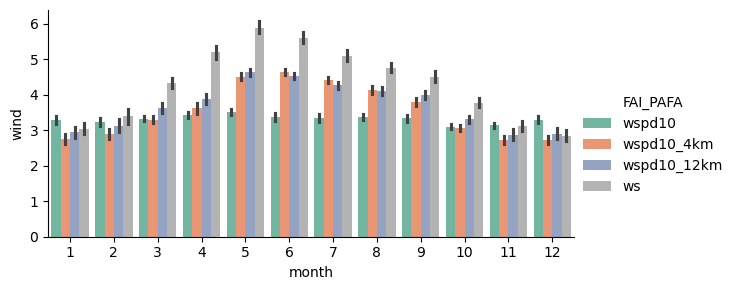

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="wind", 
            hue=teststation, palette=palette, width=0.85, height=3, aspect=2)
# g._legend.remove()

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/667053105.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)


Text(0.5, 1.0, 'teststation - dates with > 0 wind speed')

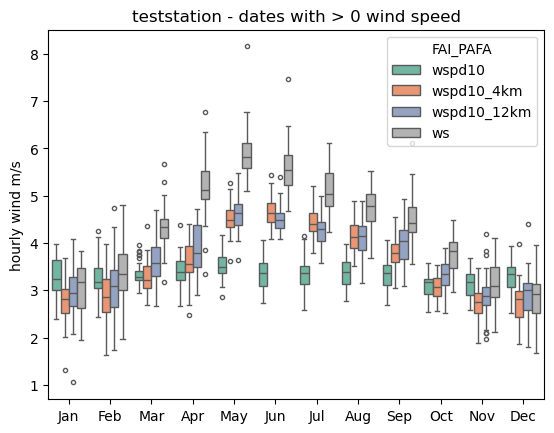

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="wind", 
            hue=teststation, palette=palette, legend=True, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('hourly wind m/s')
g.set_title(f"teststation - dates with > 0 wind speed")

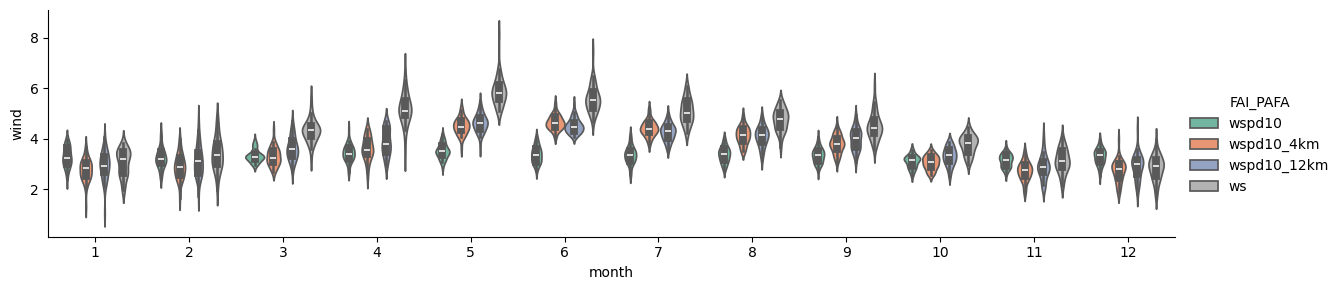

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind", 
            hue=teststation, palette=palette, height=3, aspect=4)


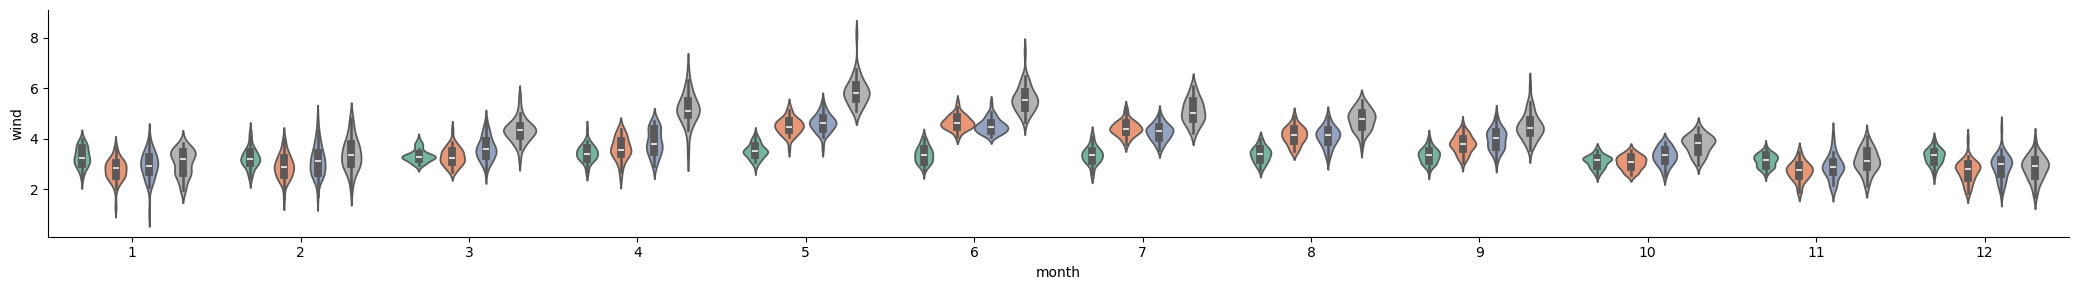

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="wind", 
            hue=teststation, palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

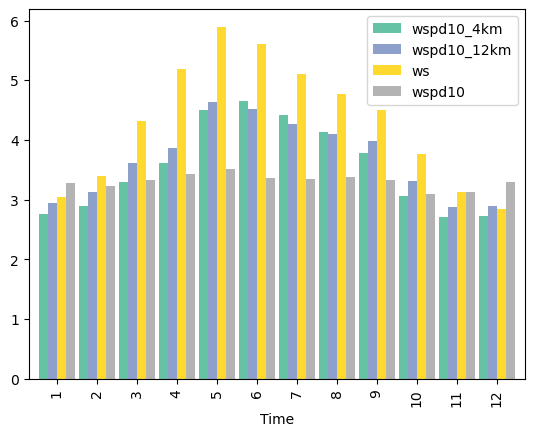

In [ ]:
monthly_DF.drop(columns=['month', 'year']).groupby(monthly_DF.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

### Make all plots and statistics

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1943355555.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1943355555.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWa

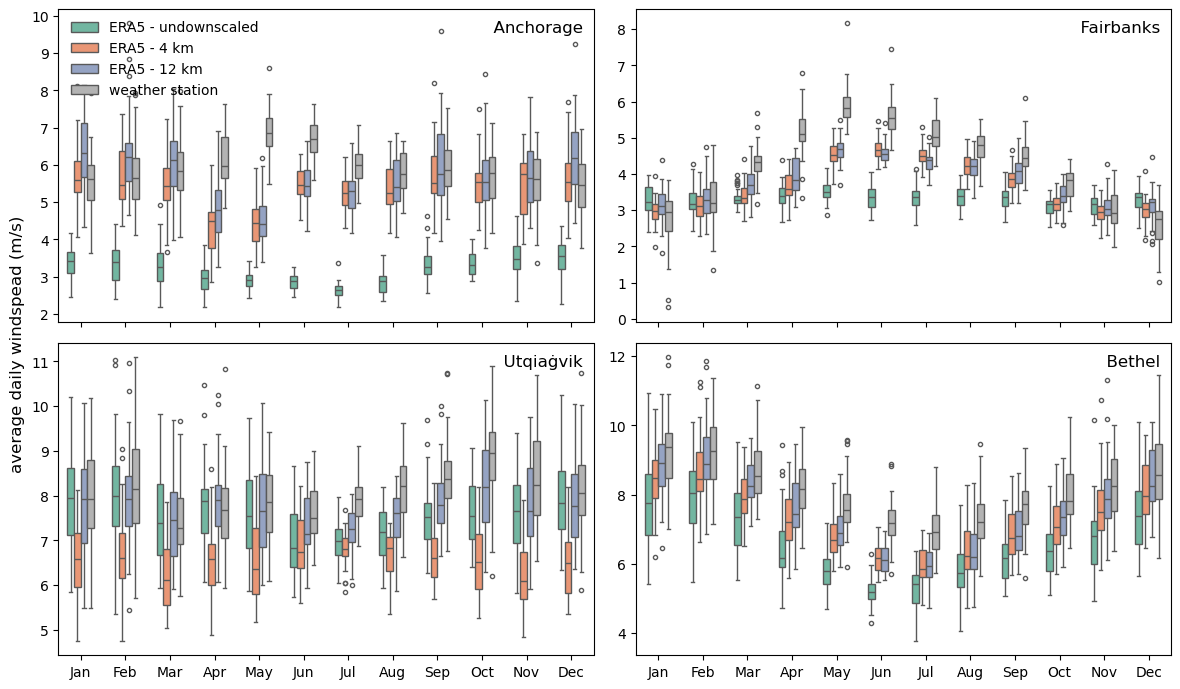

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    location = locations[station]
    monthly_DF = get_monthly(compDF, 
                        startdate=startdate, enddate=enddate)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_ERA5_2.format(
    airport=stations[station]), skiprows=2)
    monthly_DF['wspd10'] = monthly_undownscaled['wsp10'].values 
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF))
    df_forplot = pd.melt(monthly_DF.reset_index(), id_vars=[monthly_DF.index.name, 'year', 'month'], 
        value_vars=['wspd10', 'wspd10_4km', 'wspd10_12km', 'ws'], value_name='wind', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="wind", 
            hue=station, palette=palette, width=0.6, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('')
    # if ii%2:
    #     g.set_ylabel('')
    # else:
    #     g.set_ylabel('')
    ax.set_title('  ' + location + '  ', loc='right', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - undownscaled', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.supylabel('average daily windspead (m/s)')
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.98), frameon=False)
plt.tight_layout()

In [ ]:
fn = f"wind_stations_monthly_distribution_box_{startdate[:4]}-{enddate[:4]}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
monthly_DF

,wspd10_4km,wspd10_12km,ws,year,month
Time,,,,,
1980-01-31,8.112419,8.152903,7.943098,1980,1
1980-02-29,6.985414,7.839586,6.665022,1980,2
1980-03-31,4.909258,5.716710,5.770978,1980,3
1980-04-30,4.563033,5.064167,7.625391,1980,4
1980-05-31,4.563065,4.654903,7.827303,1980,5
...,...,...,...,...,...
2019-08-31,5.187355,4.919516,5.372979,2019,8
2019-09-30,5.545200,6.156167,5.294889,2019,9
2019-10-31,6.588097,7.107806,6.666330,2019,10


In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    location = locations[station]
    monthly_DF = get_monthly(compDF, 
                        startdate=startdate, enddate=enddate)
    monthly_DF.index.name = 'Time'
    results.extend(get_stats(station, monthly_DF))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/1654113850.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).mean()


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF

,location,variable,month,mean_monthly_wspd,trend,p_value,r_value
0,PANC,ws,1,5.579380,-0.039072,0.000065,-0.588398
1,PANC,ws,2,5.712088,-0.046223,0.000171,-0.560154
2,PANC,ws,3,5.892847,-0.014684,0.175383,-0.218591
3,PANC,ws,4,6.134023,-0.014286,0.124031,-0.247237
4,PANC,ws,5,6.836781,-0.002189,0.811044,-0.039025
...,...,...,...,...,...,...,...
139,PABE,wspd10_12km,8,6.322330,-0.012712,0.213657,-0.200986
140,PABE,wspd10_12km,9,6.949668,-0.015849,0.168385,-0.222099
141,PABE,wspd10_12km,10,7.353198,0.009873,0.388272,0.140183
142,PABE,wspd10_12km,11,7.911085,0.002700,0.855340,0.029763


In [ ]:
tableDF = resultsDF.query('variable != "wspd10_12km"')
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
tableDF['strtrend'] = tableDF['trend'].round(4).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/3373280386.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/3373280386.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tableDF['strtrend'] = tableDF['trend'].round(4).astype(str)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_71501/3373280386.py:4: SettingWithCopyWarning: 
A value is trying to be set

In [ ]:
tableDF

,location,variable,month,mean_monthly_wspd,trend,p_value,r_value,ID,strtrend,sigtrend
0,PANC,ws,1,5.579380,-0.039072,0.000065,-0.588398,PANC: ws,-0.0391,-0.0391 (**)
1,PANC,ws,2,5.712088,-0.046223,0.000171,-0.560154,PANC: ws,-0.0462,-0.0462 (**)
2,PANC,ws,3,5.892847,-0.014684,0.175383,-0.218591,PANC: ws,-0.0147,-0.0147
3,PANC,ws,4,6.134023,-0.014286,0.124031,-0.247237,PANC: ws,-0.0143,-0.0143
4,PANC,ws,5,6.836781,-0.002189,0.811044,-0.039025,PANC: ws,-0.0022,-0.0022
...,...,...,...,...,...,...,...,...,...,...
127,PABE,wspd10_4km,8,6.342470,-0.013171,0.199856,-0.207057,PABE: wspd10_4km,-0.0132,-0.0132
128,PABE,wspd10_4km,9,6.872556,-0.015003,0.182582,-0.215086,PABE: wspd10_4km,-0.015,-0.015
129,PABE,wspd10_4km,10,7.125889,0.010176,0.362735,0.147804,PABE: wspd10_4km,0.0102,0.0102
130,PABE,wspd10_4km,11,7.558631,0.002714,0.844823,0.031953,PABE: wspd10_4km,0.0027,0.0027


In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
PABE: ws,0.0079,0.0038,-0.0217 (*),0.0021,0.0127,-0.0028,0.0064,0.0022,-0.0036,-0.0027,0.002,0.0016
PABE: wspd10_4km,-0.0058,0.0135,-0.0187 (**),0.0046,-0.0019,-0.0045,-0.0013,-0.0132,-0.015,0.0102,0.0027,-0.0172
PABR: ws,0.0166,0.0399 (**),0.013,0.0108,-0.0046,0.0144,0.0046,-0.0057,-0.01,0.0372 (**),0.0456 (**),0.0177
PABR: wspd10_4km,-0.0037,0.0193,0.0107,0.0127,-0.0029,0.0111,0.0011,0.0001,-0.0056,0.0316 (**),0.0029,-0.0103
PAFA: ws,-0.0005,-0.0023,-0.0003,0.0005,-0.0158 (**),-0.0216 (**),-0.0227 (**),-0.02 (**),-0.0215 (**),-0.009 (*),0.0038,0.0094
PAFA: wspd10_4km,-0.0071,-0.0003,-0.004,0.0093,0.0005,-0.0028,-0.0042,-0.0081 (*),-0.0048,-0.0034,0.0003,0.0002
PANC: ws,-0.0391 (**),-0.0462 (**),-0.0147,-0.0143,-0.0022,-0.0162 (**),-0.0149 (**),-0.0173 (**),-0.0211 (**),-0.0176 (*),-0.0058,-0.0083
PANC: wspd10_4km,-0.0216 (**),-0.0188,0.0072,0.0137,0.0356 (**),-0.0047,-0.0118 (*),0.0006,0.0035,0.005,0.0174,0.0133
